In [1]:
# PyTorch 및 이미지 처리 라이브러리
import torch
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

print("PyTorch version :", torch.__version__)
print("Torchvision version :", torchvision.__version__)

PyTorch version : 2.13.0+cpu
Torchvision version : 0.28.0+cpu


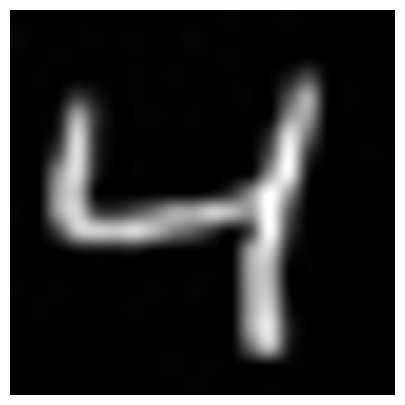

PIL image size : (224, 224)
img_tensor.shape : torch.Size([3, 224, 224])


In [ ]:
# 2. 이미지 로드 및 전처리
img_path = "data/four.jpg"

src = Image.open(img_path).convert("RGB").resize((244, 244))
plt.figure(figsize=(5, 5))
plt.imshow(src)
plt.axis("off")
plt.show()

img = Image.open(img_path).convert("RGB").resize((224, 224))
print("PIL image size :", img.size)

# PyTorch는 이미지 데이터를 기본적으로 [C, H, W] 형태의 Tensor로 사용한다.
img_tensor = transforms.ToTensor()(img)
print("img_tensor.shape :", img_tensor.shape)

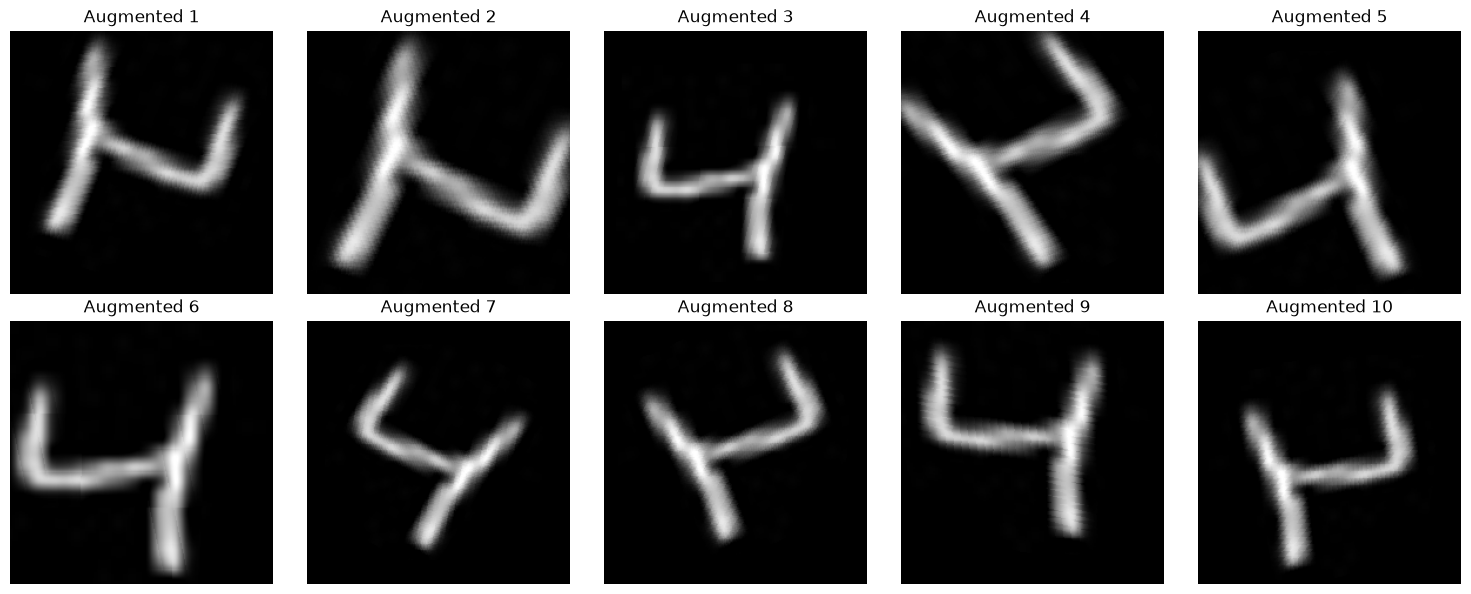

In [3]:
# 3. PyTorch 데이터 증강 설정
# Keras의 ImageDataGenerator에 대응하는 torchvision 변환이다.

augment_transform = transforms.Compose([
    transforms.RandomRotation(degrees=30),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        shear=(-10, 10),
        scale=(0.8, 1.2)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
])

# 동일한 원본 이미지에 매번 랜덤 변환을 적용한다.
augmented_images = []

for _ in range(10):
    aug_img = augment_transform(img)
    augmented_images.append(aug_img)

# 4. 증강 이미지 10개 시각화
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, aug_img in enumerate(augmented_images):
    axes[i].imshow(aug_img)
    axes[i].axis("off")
    axes[i].set_title(f"Augmented {i+1}")

plt.tight_layout()
plt.show()

In [ ]:
# MNIST 데이터셋 다운로드 및 로드
mnist_train_raw = datasets.MNIST(
    root="./data",
    train=True,
    download=True
)

mnist_test_raw = datasets.MNIST(
    root="./data",
    train=False,
    download=True
)

print("학습 데이터 :", len(mnist_train_raw))
print("테스트 데이터 :", len(mnist_test_raw))

학습 데이터 : 60000
테스트 데이터 : 10000


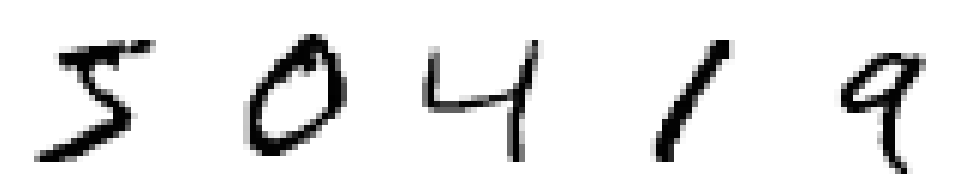

In [13]:
# 격자 형태로 이미지를 출력하는 함수
def draw_images(n, data):
    fig, ax = plt.subplots(
        1, n,
        sharex=True,
        sharey=True,
        figsize=(10, 2)
    )

    if n == 1:
        ax = [ax]

    for i in range(n):
        image = data[i]
        if torch.is_tensor(image):
            image = image.squeeze().cpu().numpy()

        ax[i].imshow(image, cmap="Greys")
        ax[i].axis("off")

    plt.tight_layout()
    plt.show()

draw_images(5, mnist_train_raw.data)

In [ ]:
# 데이터셋의 정보 요약
X_train = mnist_train_raw.data
y_train = mnist_train_raw.targets

X_test = mnist_test_raw.data
y_test = mnist_test_raw.targets

print("학습 데이터 :", X_train.shape, y_train.shape)
print("테스트 데이터 :", X_test.shape, y_test.shape)

print(f"학습 데이터의 최소값 : {X_train.min().item()}")
print(f"학습 데이터의 최대값 : {X_train.max().item()}")
print(f"학습 데이터의 평균값 : {X_train.float().mean().item():.4f}")
print(f"학습 데이터의 표준편차 : {X_train.float().std().item():.4f}")

학습 데이터 : torch.Size([60000, 28, 28]) torch.Size([60000])
테스트 데이터 : torch.Size([10000, 28, 28]) torch.Size([10000])
학습 데이터의 최소값 : 0
학습 데이터의 최대값 : 255
학습 데이터의 평균값 : 33.3184
학습 데이터의 표준편차 : 78.5675


In [16]:
# PyTorch의 ToTensor()를 사용하면
# uint8 [0, 255] 범위의 픽셀이 float [0, 1] 범위로 자동 변환된다.

to_tensor = transforms.ToTensor()

print(f'mnist_train_raw[0][0] : {type(mnist_test_raw[0][0])}')

sample_tensor = to_tensor(mnist_train_raw[0][0])

print("Tensor shape :", sample_tensor.shape)
print(f"최소값 : {sample_tensor.min().item():.4f}")
print(f"최대값 : {sample_tensor.max().item():.4f}")
print(f"평균값 : {sample_tensor.mean().item():.4f}")
print(f"표준편차 : {sample_tensor.std().item():.4f}")

mnist_train_raw[0][0] : <class 'PIL.Image.Image'>
Tensor shape : torch.Size([1, 28, 28])
최소값 : 0.0000
최대값 : 1.0000
평균값 : 0.1377
표준편차 : 0.3125


In [17]:
# 전체 학습 데이터의 평균과 표준편차를 이용한 표준화이다.
#PyTorch에서는 `transforms.Normalize(mean, std)`를 사용한다.

# MNIST 전체 학습 데이터의 평균과 표준편차 계산
mnist_float = X_train.float() / 255.0

mnist_mean = mnist_float.mean().item()
mnist_std = mnist_float.std().item()

print("MNIST mean :", mnist_mean)
print("MNIST std  :", mnist_std)

mnist_normalize = transforms.Normalize(
    mean=[mnist_mean],
    std=[mnist_std]
)

# ToTensor -> Normalize
normalized_transform = transforms.Compose([
    transforms.ToTensor(),
    mnist_normalize
])

sample_normalized = normalized_transform(mnist_train_raw[0][0])

print("정규화 후 shape :", sample_normalized.shape)
print(f"정규화 후 평균 : {sample_normalized.mean().item():.4f}")
print(f"정규화 후 표준편차 : {sample_normalized.std().item():.4f}")

MNIST mean : 0.13066047430038452
MNIST std  : 0.30810782313346863
정규화 후 shape : torch.Size([1, 28, 28])
정규화 후 평균 : 0.0228
정규화 후 표준편차 : 1.0144


In [18]:
# 정규화된 MNIST 이미지를 배치 단위로 확인
mnist_normalized_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=normalized_transform
)

loader = torch.utils.data.DataLoader(
    mnist_normalized_dataset,
    batch_size=9,
    shuffle=False
)

X_batch, y_batch = next(iter(loader))

print(f"배치 데이터 : {X_batch.shape}")
print(f"배치 데이터의 최소값 : {X_batch.min().item():.4f}")
print(f"배치 데이터의 최대값 : {X_batch.max().item():.4f}")
print(f"배치 데이터의 평균값 : {X_batch.mean().item():.4f}")
print(f"배치 데이터의 표준편차 : {X_batch.std().item():.4f}")


배치 데이터 : torch.Size([9, 1, 28, 28])
배치 데이터의 최소값 : -0.4241
배치 데이터의 최대값 : 2.8215
배치 데이터의 평균값 : -0.0409
배치 데이터의 표준편차 : 0.9532


In [19]:
# MNIST 원본 데이터셋
mnist_base = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

def show_transform(transform, n=5, title="Augmented"):
    fig, axes = plt.subplots(1, n, figsize=(10, 2))

    if n == 1:
        axes = [axes]

    for i in range(n):
        image, label = mnist_base[i]
        augmented = transform(image)

        # Tensor [C,H,W] -> [H,W]
        augmented = augmented.squeeze().numpy()

        axes[i].imshow(augmented, cmap="Greys")
        axes[i].axis("off")
        axes[i].set_title(f"{title} {i+1}")

    plt.tight_layout()
    plt.show()

def show_grid_transform(transform, row=3, col=5, title="Augmented"):
    fig, axes = plt.subplots(row, col, figsize=(8, 5))
    axes = np.asarray(axes).reshape(row, col)

    for idx in range(row * col):
        image, label = mnist_base[idx]
        augmented = transform(image)
        augmented = augmented.squeeze().numpy()

        r = idx // col
        c = idx % col

        axes[r, c].imshow(augmented, cmap="Greys")
        axes[r, c].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


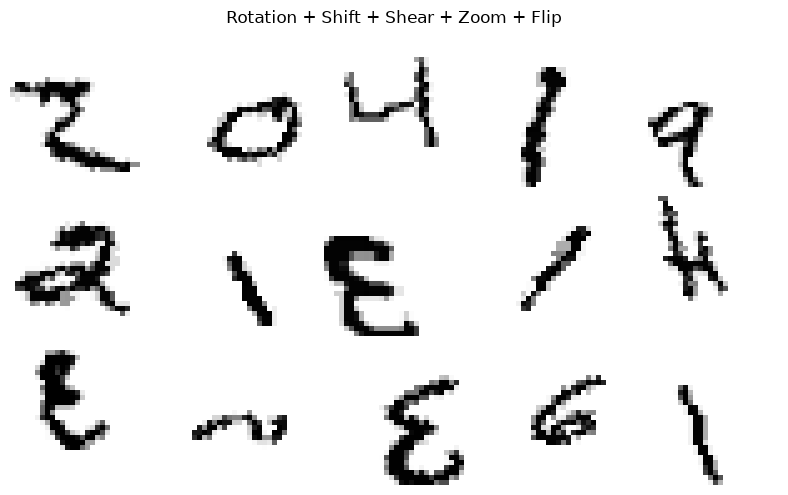

In [20]:
# 여러 변환을 한 번에 적용
transform = transforms.Compose([
    transforms.RandomRotation(40),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.2, 0.2),
        shear=(-10, 10),
        scale=(0.8, 1.2)
    ),
    transforms.RandomHorizontalFlip(p=0.5)
])

show_grid_transform(transform, title="Rotation + Shift + Shear + Zoom + Flip")


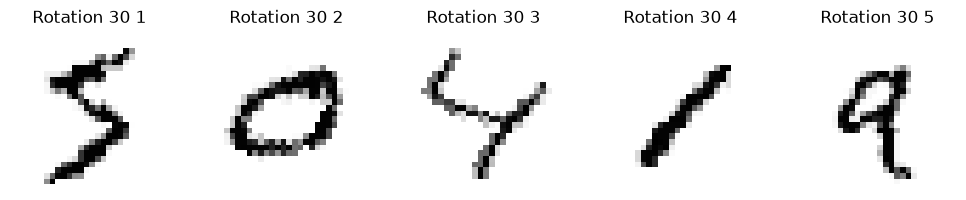

In [21]:
# 0도에서 30도 범위에서 랜덤하게 회전
transform = transforms.RandomRotation(degrees=30)
show_transform(transform, title="Rotation 30")


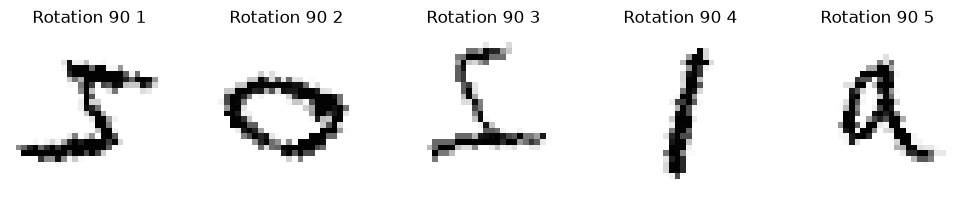

In [22]:
# 0도에서 90도 범위에서 랜덤하게 회전
transform = transforms.RandomRotation(degrees=90)
show_transform(transform, title="Rotation 90")


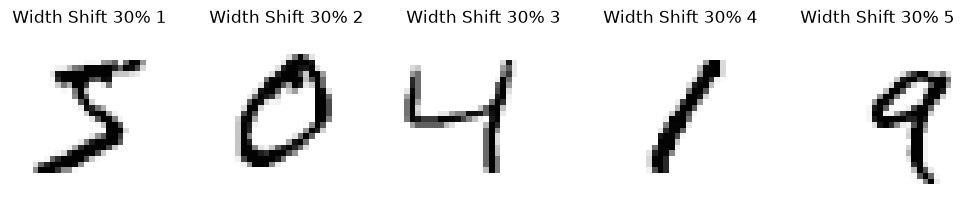

In [23]:
# 원래 이미지의 가로 방향을 최대 30%까지 랜덤 이동
transform = transforms.RandomAffine(
    degrees=0,
    translate=(0.3, 0)
)
show_transform(transform, title="Width Shift 30%")


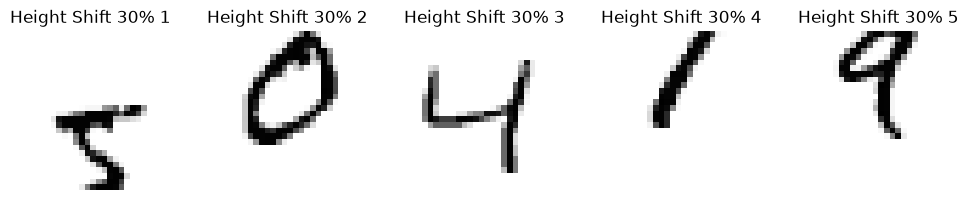

In [24]:
# 원래 이미지의 세로 방향을 최대 30%까지 랜덤 이동
transform = transforms.RandomAffine(
    degrees=0,
    translate=(0, 0.3)
)
show_transform(transform, title="Height Shift 30%")


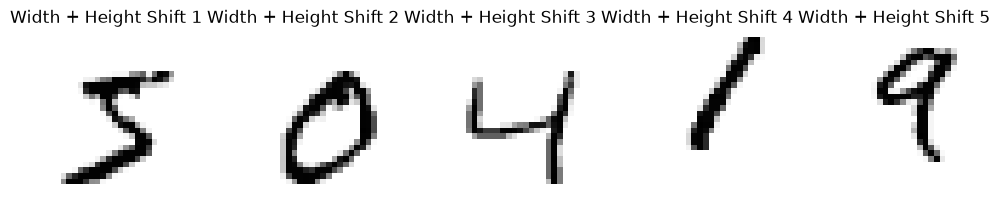

In [25]:
# 가로·세로 방향을 각각 최대 20%까지 랜덤 이동
shift = 0.2

transform = transforms.RandomAffine(
    degrees=0,
    translate=(shift, shift)
)

show_transform(transform, title="Width + Height Shift")


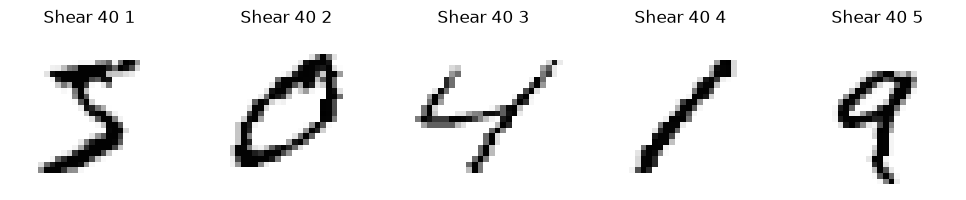

In [26]:
# 전단(Shear) 변환
# torchvision에서는 shear를 각도 단위로 지정한다.
shear = 40

transform = transforms.RandomAffine(
    degrees=0,
    shear=(-shear, shear)
)

show_transform(transform, title="Shear 40")


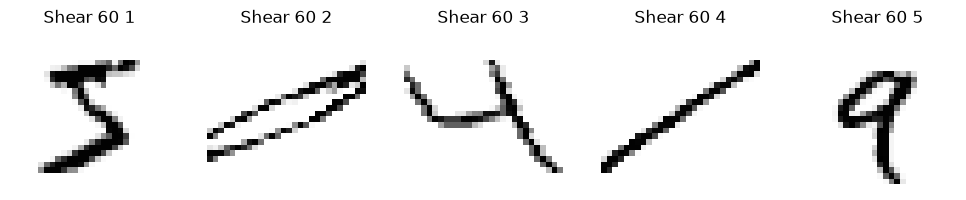

In [27]:
shear = 60

transform = transforms.RandomAffine(
    degrees=0,
    shear=(-shear, shear)
)

show_transform(transform, title="Shear 60")


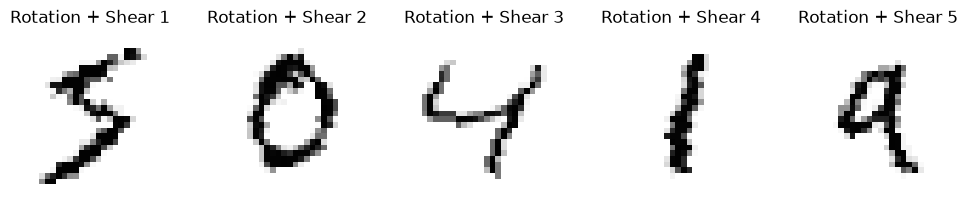

In [28]:
# 회전 + 전단
transform = transforms.Compose([
    transforms.RandomRotation(40),
    transforms.RandomAffine(
        degrees=0,
        shear=(-30, 30)
    )
])

show_transform(transform, title="Rotation + Shear")


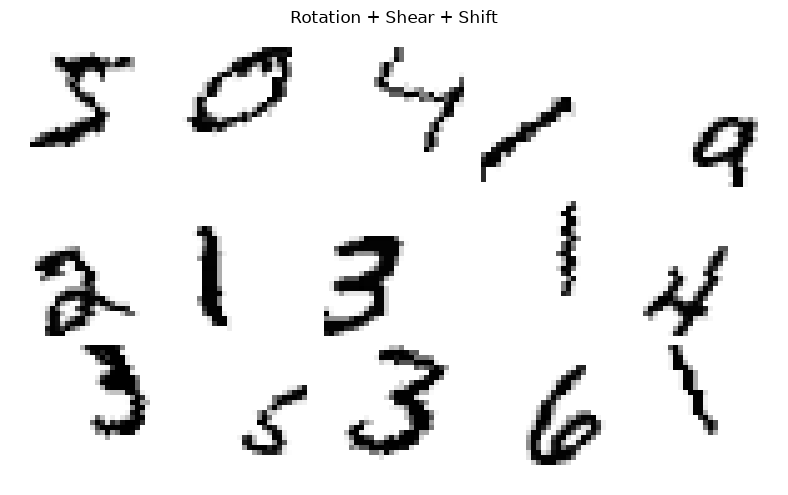

In [29]:
# 회전 + 전단 + 이동
transform = transforms.Compose([
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0,
        shear=(-25, 25),
        translate=(0.25, 0.25)
    )
])

show_grid_transform(transform, title="Rotation + Shear + Shift")


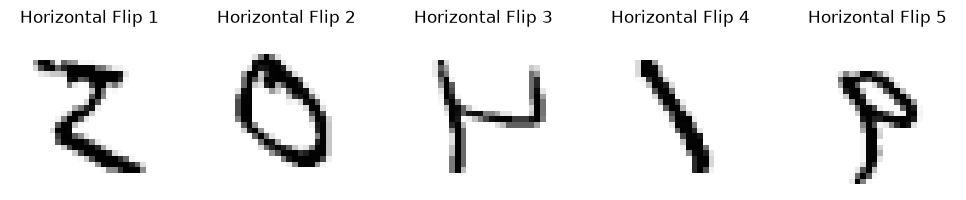

In [30]:
# 좌우 반전
transform = transforms.RandomHorizontalFlip(p=1.0)
show_transform(transform, title="Horizontal Flip")

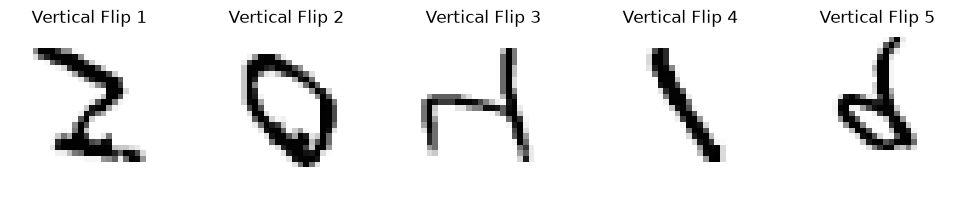

In [31]:
# 상하 반전
transform = transforms.RandomVerticalFlip(p=1.0)
show_transform(transform, title="Vertical Flip")


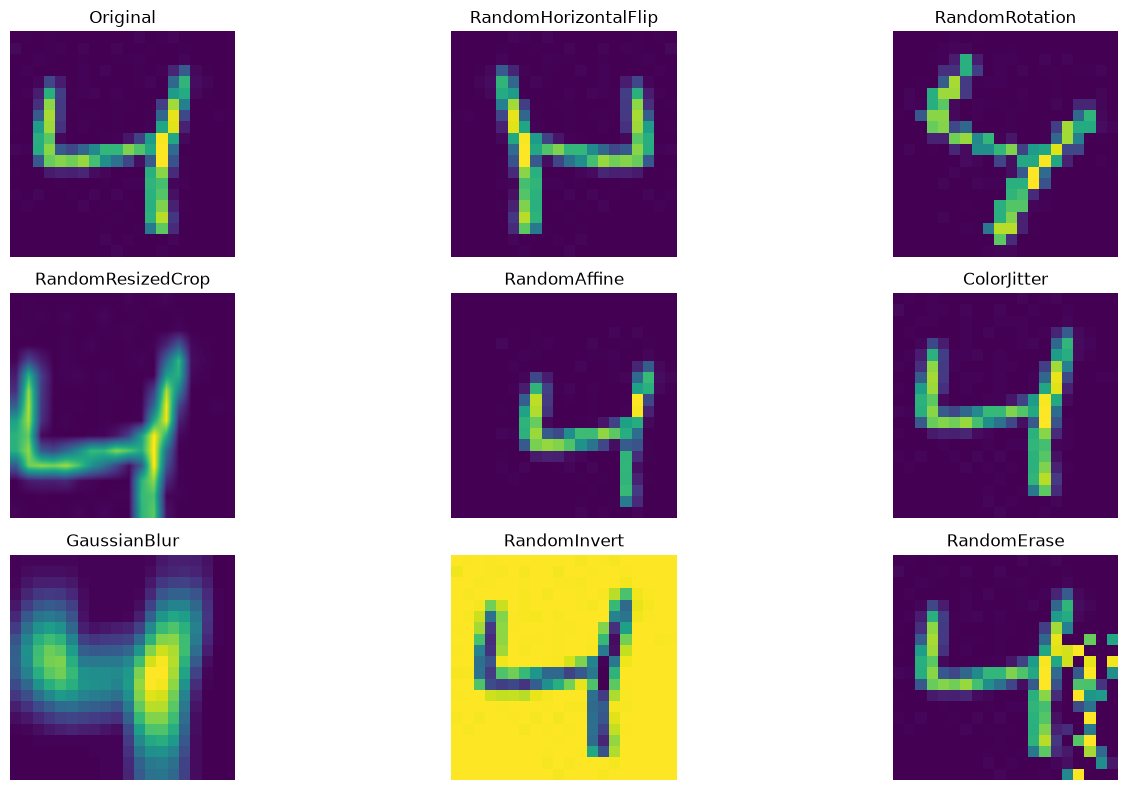

In [32]:
import torch
import torchvision.io as io
import torchvision.transforms.v2 as transforms
import matplotlib.pyplot as plt

# 1. 이미지 로드 (PyTorch Tensor 형식: C x H x W)
image_path = "data/four.jpg"  # 사용하고자 하는 이미지 경로
original_tensor = io.read_image(image_path)

# 2. 다양한 이미지 증강(Augmentation) 기법 정의
augmentation_dict = {
    # 2-1. 위치 및 기하학적 변형 (Spatial Transforms)
    "RandomHorizontalFlip": transforms.RandomHorizontalFlip(p=1.0),  # 좌우 반전
    "RandomRotation": transforms.RandomRotation(degrees=45),           # 랜덤 회전 (±45도)
    "RandomResizedCrop": transforms.RandomResizedCrop(size=(224, 224), scale=(0.5, 1.0)), # 크롭 후 리사이즈
    "RandomAffine": transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), scale=(0.8, 1.2)), # 평행이동 및 확대/축소

    # 2-2. 색상 및 화질 변형 (Color & Quality Transforms)
    "ColorJitter": transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5), # 밝기, 대비, 채도 변형
    "GaussianBlur": transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5.0)),       # 가우시안 블러 (흐림)
    "RandomInvert": transforms.RandomInvert(p=1.0),                                     # 색상 반전

    # 2-3. 영역 가리기 기법 (Erasing)
    # Erasing은 0~1 범위의 Float Tensor로 변환 후 적용해야 함
    "RandomErase": transforms.Compose([
        transforms.ToDtype(torch.float32, scale=True),
        transforms.RandomErasing(p=1.0, scale=(0.02, 0.2), value='random')
    ])
}

# 3. 시각화를 위한 함수 (Tensor C,H,W -> Numpy H,W,C 변환)
def tensor_to_display(tensor):
    # Float 텐서인 경우 0~255 uint8 범위로 변경
    if tensor.dtype != torch.uint8:
        tensor = (tensor * 255).clamp(0, 255).to(torch.uint8)
    return tensor.permute(1, 2, 0).cpu().numpy()

# 4. 시각화 수행
plt.figure(figsize=(15, 8))

# 원본 출력
plt.subplot(3, 3, 1)
plt.imshow(tensor_to_display(original_tensor))
plt.title("Original")
plt.axis("off")

# 각 증강 기법 적용 및 출력
for idx, (name, aug) in enumerate(augmentation_dict.items(), start=2):
    augmented_tensor = aug(original_tensor)

    plt.subplot(3, 3, idx)
    plt.imshow(tensor_to_display(augmented_tensor))
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()